# MLflow Evaluation Run Comparison

Compare RAGAS scores across multiple MLflow runs side-by-side.

**Input:** `RUNS` list of `(run_id, label)` pairs.  
**Output:** Tables and charts aggregated by overall, `question_class`, `subdomain`, and `(question_class, subdomain)`.

In [18]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

In [19]:
# ── Configuration ─────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = "http://localhost:8567"

# Each entry: (run_id, human_readable_label)
RUNS = [
    ("f6d783f661a644a58865384534021c32", "baseline/semantic/4o-mini"),
    ("79ac6798bfab4f228fdb0cb88a30bb16", "baseline/semantic/4o-mini/run_2"),
    ("144d504d4b1b454f8505f54697c69250", "baseline/bm25/4o-mini"),
    ("2ebab2b7d6ad46859eab992a06c5ccad", "baseline/hybrid/4o-mini"),
    ("92647f9427f74a0ea710d0cf731ec0ea", "query_rewriting/semantic/gpt-4o-mini"),
    ("e5483a9635b34c8895ecdfabc45674c4", "query_rewriting/bm25/4o-mini"),
    ("412a730db5e04a4da436218d6321d1cd", "query_rewriting/hybrid/4o-mini"),
    ("7b33b7a6b88b420e93d6c56f8bca4416", "rag_agent/semantic/gpt-4o-mini"),
    ("2c80aecbb48d4bf68efce97806509159", "rag_agent/bm25/4o-mini"),
    ("9b9b5ef53cfd4bb1a8ad8324ce01e251", "rag_agent/bm25/4o-mini/run_2"),
    ("9df381d8997646e797d34917dd394dee", "rag_agent/hybrid/4o-mini"),
    ("d0fd5a3181f947a9a993417e86c50e28", "rag_agent/hybrid/4o-mini/run_2"),
    ("7e34b19e653d4df09f9dc59d9a488d86", "rag_agent/hybrid/gemma4:e4b"),
    ("801c6a24a60b4f689a38fcdb1de87e49", "rag_agent/hybrid/qwen3.5:9b"),
    ("64308a1718224160b777630198d0c1ad", "rag_agent/hybrid/qwen3.5:9b/run_2"),
    ("9d312a36ef2f4332b200b620919bd202", "rag_agent/hybrid/gpt-5.4"),
    ("7021198023d34038929cdeebe7cbea4c", "rag_agent/hybrid/gpt-5.4/run_2"),
    
]

RAGAS_TABLE_ARTIFACT = "ragas_scores.json"

METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]

# Short metric names for chart axis labels.
METRIC_SHORT = {
    "faithfulness": "Faith.",
    "context_precision": "Ctx Prec.",
    "context_recall": "Ctx Rec.",
    "answer_relevance": "Ans Rel.",
    "factual_correctness": "FC",
    "factual_correctness_recall": "FC Rec.",
}

# Question classes excluded from subdomain and overall aggregations.
# "unanswerable" questions score 0 on retrieval/relevance metrics by design,
# so including them in averages would unfairly dilute results.
EXCLUDE_QUESTION_CLASSES = ["unanswerable"]

# ── Derived convenience maps (do not edit) ────────────────────────────────────
RUN_IDS    = [r for r, _ in RUNS]
RUN_LABELS = {r: lbl for r, lbl in RUNS}

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Runs configured: {len(RUNS)}")
for rid, lbl in RUNS:
    print(f"  {rid[:8]}…  →  {lbl}")

Tracking URI: http://localhost:8567
Runs configured: 17
  f6d783f6…  →  baseline/semantic/4o-mini
  79ac6798…  →  baseline/semantic/4o-mini/run_2
  144d504d…  →  baseline/bm25/4o-mini
  2ebab2b7…  →  baseline/hybrid/4o-mini
  92647f94…  →  query_rewriting/semantic/gpt-4o-mini
  e5483a96…  →  query_rewriting/bm25/4o-mini
  412a730d…  →  query_rewriting/hybrid/4o-mini
  7b33b7a6…  →  rag_agent/semantic/gpt-4o-mini
  2c80aecb…  →  rag_agent/bm25/4o-mini
  9b9b5ef5…  →  rag_agent/bm25/4o-mini/run_2
  9df381d8…  →  rag_agent/hybrid/4o-mini
  d0fd5a31…  →  rag_agent/hybrid/4o-mini/run_2
  7e34b19e…  →  rag_agent/hybrid/gemma4:e4b
  801c6a24…  →  rag_agent/hybrid/qwen3.5:9b
  64308a17…  →  rag_agent/hybrid/qwen3.5:9b/run_2
  9d312a36…  →  rag_agent/hybrid/gpt-5.4
  70211980…  →  rag_agent/hybrid/gpt-5.4/run_2


In [20]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def list_artifacts_recursive(run_id: str, path: str = ""):
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(list_artifacts_recursive(run_id, art.path))
    return items


def normalize_logged_table(json_obj) -> pd.DataFrame:
    if isinstance(json_obj, list):
        return pd.DataFrame(json_obj)
    if isinstance(json_obj, dict):
        if "data" in json_obj and "columns" in json_obj:
            return pd.DataFrame(json_obj["data"], columns=json_obj["columns"])
        return pd.DataFrame(json_obj)
    raise ValueError("Unsupported ragas_scores.json structure")


def load_ragas_table(run_id: str) -> pd.DataFrame | None:
    artifact_paths = list_artifacts_recursive(run_id)
    matches = [p for p in artifact_paths if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        return None
    local_path = client.download_artifacts(run_id, matches[0])
    with open(local_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    df = normalize_logged_table(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def run_label(run_id: str) -> str:
    return RUN_LABELS.get(run_id, run_id[:8])

In [21]:
# ── Load data for each run ────────────────────────────────────────────────────
run_data: dict[str, pd.DataFrame] = {}
failed: list[str] = []

for run_id, label in RUNS:
    df = load_ragas_table(run_id)
    if df is None:
        print(f"  [MISS]  {run_id}  ({label}) — no {RAGAS_TABLE_ARTIFACT} found")
        failed.append(run_id)
    else:
        df["run_id"]    = run_id
        df["run_label"] = label
        run_data[run_id] = df
        print(f"  [OK]    {run_id}  ({label})  — {len(df)} rows")

if not run_data:
    raise ValueError("No ragas_scores.json found for any of the supplied run IDs.")

print(f"\nLoaded {len(run_data)}/{len(RUNS)} runs successfully.")
if failed:
    print(f"Missing: {failed}")

# Ordered label list — used to keep run order consistent across all tables/charts.
LABELS = [run_label(r) for r in RUN_IDS if r in run_data]

  [OK]    f6d783f661a644a58865384534021c32  (baseline/semantic/4o-mini)  — 20 rows


  [OK]    79ac6798bfab4f228fdb0cb88a30bb16  (baseline/semantic/4o-mini/run_2)  — 20 rows


  [OK]    144d504d4b1b454f8505f54697c69250  (baseline/bm25/4o-mini)  — 20 rows


  [OK]    2ebab2b7d6ad46859eab992a06c5ccad  (baseline/hybrid/4o-mini)  — 20 rows


  [OK]    92647f9427f74a0ea710d0cf731ec0ea  (query_rewriting/semantic/gpt-4o-mini)  — 20 rows


...

  [OK]    7e34b19e653d4df09f9dc59d9a488d86  (rag_agent/hybrid/gemma4:e4b)  — 20 rows


  [OK]    801c6a24a60b4f689a38fcdb1de87e49  (rag_agent/hybrid/qwen3.5:9b)  — 20 rows


  [OK]    64308a1718224160b777630198d0c1ad  (rag_agent/hybrid/qwen3.5:9b/run_2)  — 20 rows


  [OK]    9d312a36ef2f4332b200b620919bd202  (rag_agent/hybrid/gpt-5.4)  — 20 rows


  [OK]    7021198023d34038929cdeebe7cbea4c  (rag_agent/hybrid/gpt-5.4/run_2)  — 20 rows

Loaded 17/17 runs successfully.


In [22]:
# ── Aggregation helpers ───────────────────────────────────────────────────────
def build_comparison(group_col, exclude_classes=None) -> pd.DataFrame:
    """
    group_col      : str | list[str] | None — column(s) to group by.
                     None → single overall mean row per run.
    exclude_classes: list[str] | None — question_class values to drop first.

    Returns:
      group_col=None  → DataFrame  rows=runs, cols=metrics
      otherwise       → DataFrame  MultiIndex cols (metric, run), rows=group values
    """
    frames = {}
    for run_id, df in run_data.items():
        label = run_label(run_id)
        sub = df.copy()
        if exclude_classes:
            sub = sub[~sub["question_class"].isin(exclude_classes)]
        metrics_present = [c for c in METRIC_COLS if c in sub.columns]
        if group_col is None:
            frames[label] = sub[metrics_present].mean(numeric_only=True).rename(label)
        else:
            agg = sub.groupby(group_col, dropna=False)[metrics_present].mean(numeric_only=True)
            agg.columns = pd.MultiIndex.from_tuples([(c, label) for c in agg.columns])
            frames[label] = agg

    if group_col is None:
        return pd.DataFrame(frames).T.loc[LABELS]  # preserve run order

    combined = pd.concat(frames.values(), axis=1)
    combined.columns.names = ["metric", "run"]
    metrics_in = [c for c in METRIC_COLS if c in combined.columns.get_level_values(0)]
    combined = combined.reindex(
        columns=pd.MultiIndex.from_product([metrics_in, LABELS], names=["metric", "run"])
    )
    return combined


def metrics_present_in(df: pd.DataFrame) -> list[str]:
    if isinstance(df.columns, pd.MultiIndex):
        return [c for c in METRIC_COLS if c in df.columns.get_level_values(0)]
    return [c for c in METRIC_COLS if c in df.columns]

In [23]:
# ── Chart helpers ─────────────────────────────────────────────────────────────
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]


def grouped_bar(ax, df_rows_runs: pd.DataFrame, title: str, ylabel="Score"):
    """
    df_rows_runs: rows = group values (or single row for overall),
                  cols = run labels, values = metric score.
    Draws a grouped bar chart on `ax`.
    """
    groups   = list(df_rows_runs.index)
    runs     = list(df_rows_runs.columns)
    n_groups = len(groups)
    n_runs   = len(runs)
    width    = 0.8 / n_runs
    x        = np.arange(n_groups)

    for i, run in enumerate(runs):
        offset = (i - (n_runs - 1) / 2) * width
        vals   = df_rows_runs[run].values.astype(float)
        bars   = ax.bar(x + offset, vals, width * 0.9, label=run, color=COLORS[i % len(COLORS)])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f"{v:.2f}",
                    ha="center", va="bottom", fontsize=6, rotation=90,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [str(g) for g in groups], rotation=30, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.18)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)


def plot_overall_bars(overall: pd.DataFrame):
    """One grouped bar per metric, bars = runs."""
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    fig, ax = plt.subplots(figsize=(max(8, len(metrics) * 1.5), 4.5))
    plot_df = overall[metrics].T.copy()
    plot_df.index = short
    grouped_bar(ax, plot_df, title="Overall mean scores by metric (excluding: " + str(EXCLUDE_QUESTION_CLASSES) + ")")
    ax.set_xlabel("Metric", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_by_group(comp: pd.DataFrame, group_name: str):
    """One subplot per metric, grouped bars over group values."""
    metrics = metrics_present_in(comp)
    n = len(metrics)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4.5))
    axes_flat = np.array(axes).flatten()

    for i, metric in enumerate(metrics):
        ax     = axes_flat[i]
        subset = comp[metric].copy()  # rows=group, cols=runs
        # Shorten long index labels
        subset.index = [
            str(idx)[:35] + "…" if len(str(idx)) > 35 else str(idx)
            for idx in subset.index
        ]
        grouped_bar(ax, subset, title=metric)
        ax.set_xlabel(group_name, fontsize=8)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.suptitle(f"Scores by {group_name}", fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_radar(overall: pd.DataFrame):
    """Radar / spider chart — one polygon per run."""
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    N       = len(metrics)
    angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    for i, label in enumerate(LABELS):
        vals  = overall.loc[label, metrics].values.astype(float).tolist()
        vals += vals[:1]
        color = COLORS[i % len(COLORS)]
        ax.plot(angles, vals, color=color, linewidth=1.5, label=label)
        ax.fill(angles, vals, color=color, alpha=0.10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(short, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=6)
    ax.set_title("Overall scores — radar", fontsize=10, fontweight="bold", pad=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_heatmap(overall: pd.DataFrame, title=""):
    """Heatmap: rows=runs, cols=metrics."""
    metrics = metrics_present_in(overall)
    data    = overall[metrics].astype(float)
    data.columns = [METRIC_SHORT.get(c, c) for c in data.columns]

    fig, ax = plt.subplots(figsize=(max(6, len(metrics) * 1.2), max(2, len(LABELS) * 0.6 + 1)))
    im = ax.imshow(data.values, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8)

    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data.iloc[r, c]
            ax.text(c, r, f"{v:.3f}", ha="center", va="center", fontsize=8,
                    color="black" if 0.3 < v < 0.8 else "white")

    ax.set_title(title or "Score heatmap", fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 1. Overall mean (excluding specified question classes)

In [24]:
print(f"Excluding question classes: {EXCLUDE_QUESTION_CLASSES or 'none'}")
overall = build_comparison(group_col=None, exclude_classes=EXCLUDE_QUESTION_CLASSES)
display(overall)

Excluding question classes: ['unanswerable']


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
baseline/semantic/4o-mini,0.7185,0.6515,0.5556,0.7929,0.5007,0.6093
baseline/semantic/4o-mini/run_2,0.6477,0.6339,0.6889,0.7839,0.4767,0.6360
baseline/bm25/4o-mini,0.7973,0.7000,0.5778,0.8236,0.4853,0.6320
baseline/hybrid/4o-mini,0.8058,0.7521,0.6111,0.8889,0.4740,0.5827
query_rewriting/semantic/gpt-4o-mini,0.7093,0.5876,0.6222,0.7895,0.5167,0.6636
query_rewriting/bm25/4o-mini,0.7115,0.7673,0.7667,0.8611,0.4707,0.5767
query_rewriting/hybrid/4o-mini,0.8045,0.7146,0.6222,0.8642,0.5247,0.6560
rag_agent/semantic/gpt-4o-mini,0.7533,0.6762,0.7222,0.8499,0.4147,0.7767
rag_agent/bm25/4o-mini,0.7602,0.7735,0.6786,0.9221,0.4593,0.7933
rag_agent/bm25/4o-mini/run_2,0.7504,0.7491,0.7667,0.9324,0.4800,0.7764


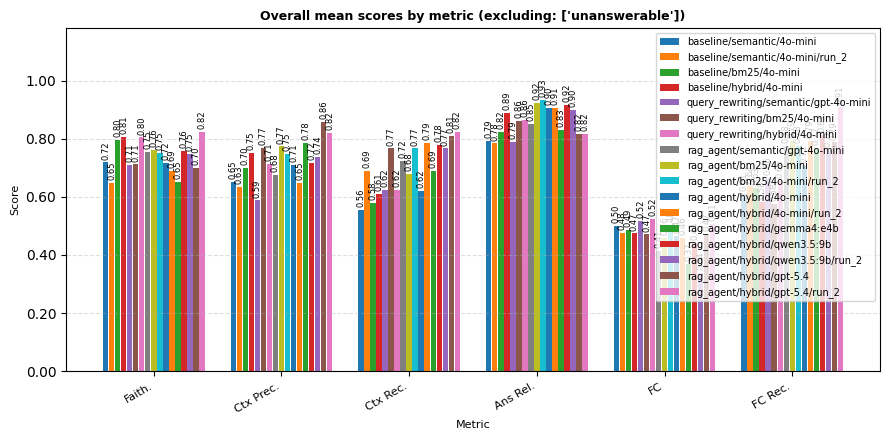

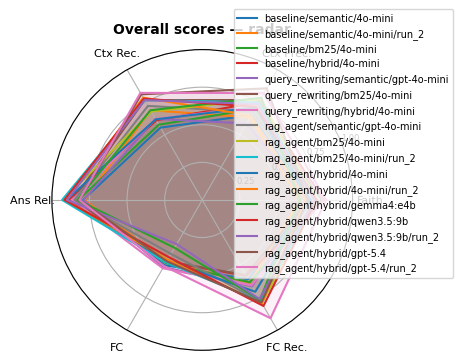

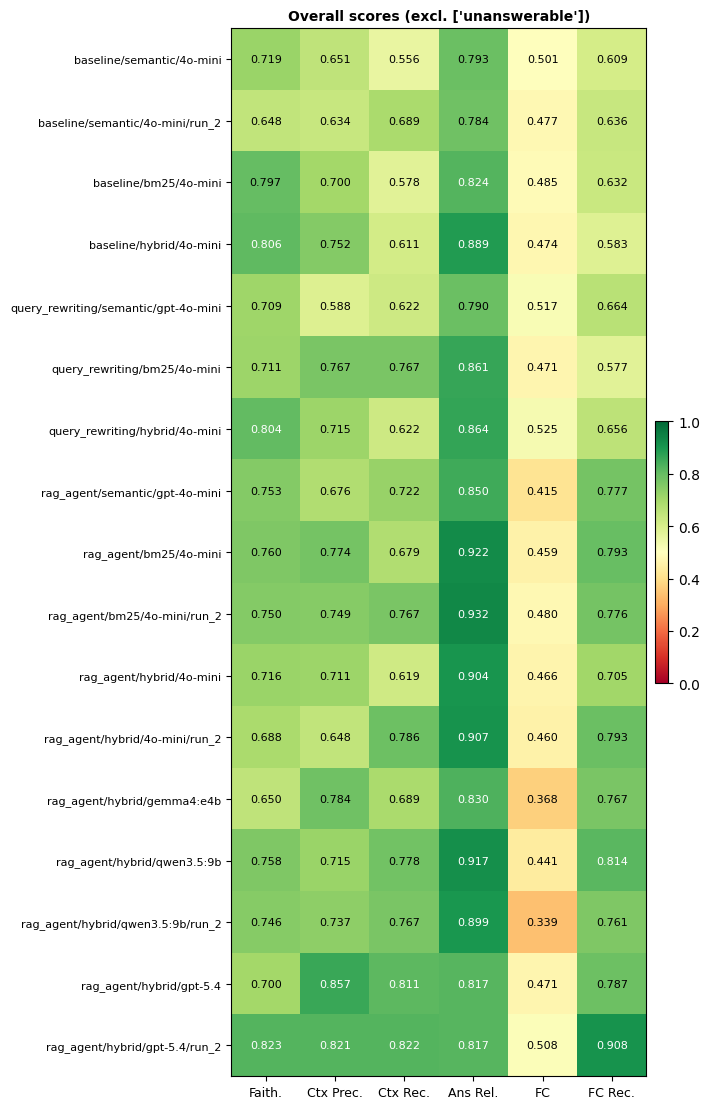

In [25]:
plot_overall_bars(overall)
plot_radar(overall)
plot_heatmap(overall, title=f"Overall scores (excl. {EXCLUDE_QUESTION_CLASSES})")

---
## 2. By `question_class`

All question classes included so you can also inspect unanswerable scores.

In [26]:
by_qclass = build_comparison(group_col="question_class", exclude_classes=None)
display(by_qclass)

metric                      faithfulness                                                                                                                                                  \
run            baseline/semantic/4o-mini baseline/semantic/4o-mini/run_2 baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting/semantic/gpt-4o-mini query_rewriting/bm25/4o-mini   
question_class                                                                                                                                                                             
fact_single                       0.8700                          0.8286                0.8000                  0.8000                               0.8667                       0.6000   
reasoning                         0.7925                          0.6930                0.6971                  0.8143                               0.7444                       0.6618   
summary                           0.4930                          0.4214                0.8947                  0.8049                               0.5168                       0.8726   
unanswerable                      0.6571                          0.8800                0.6000                  0.8000                               0.8167                       0.6000   

metric                                                                                                                                                                                    \
run            query_rewriting/hybrid/4o-mini rag_agent/semantic/gpt-4o-mini rag_agent/bm25/4o-mini rag_agent/bm25/4o-mini/run_2 rag_agent/hybrid/4o-mini rag_agent/hybrid/4o-mini/run_2   
question_class                                                                                                                                                                             
fact_single                            0.9333                         0.9200                 0.8833                       0.9000                   0.9000                         0.8533   
reasoning                              0.7254                         0.6875                 0.6137                       0.6761                   0.6151                         0.5096   
summary                                0.7548                         0.6392                 0.7544                       0.6563                   0.6116                         0.6606   
unanswerable                           0.5500                         0.2308                 0.3039                       0.2333                   0.3103                         0.2908   

metric                                                                                                                                                                   context_precision  \
run            rag_agent/hybrid/gemma4:e4b rag_agent/hybrid/qwen3.5:9b rag_agent/hybrid/qwen3.5:9b/run_2 rag_agent/hybrid/gpt-5.4 rag_agent/hybrid/gpt-5.4/run_2 baseline/semantic/4o-mini   
question_class                                                                                                                                                                               
fact_single                         0.7689                      0.9167                            0.8400                   0.7333                         0.8417                    0.7706   
reasoning                           0.3903                      0.6473                            0.6976                   0.7833                         0.8421                    0.6561   
summary                             0.7603                      0.6429                            0.6714                   0.5898                         0.7911                    0.5278   
unanswerable                        0.7500                      0.3222                            0.2252                   0.3512                         0.4719                    0.0000   

metric                             

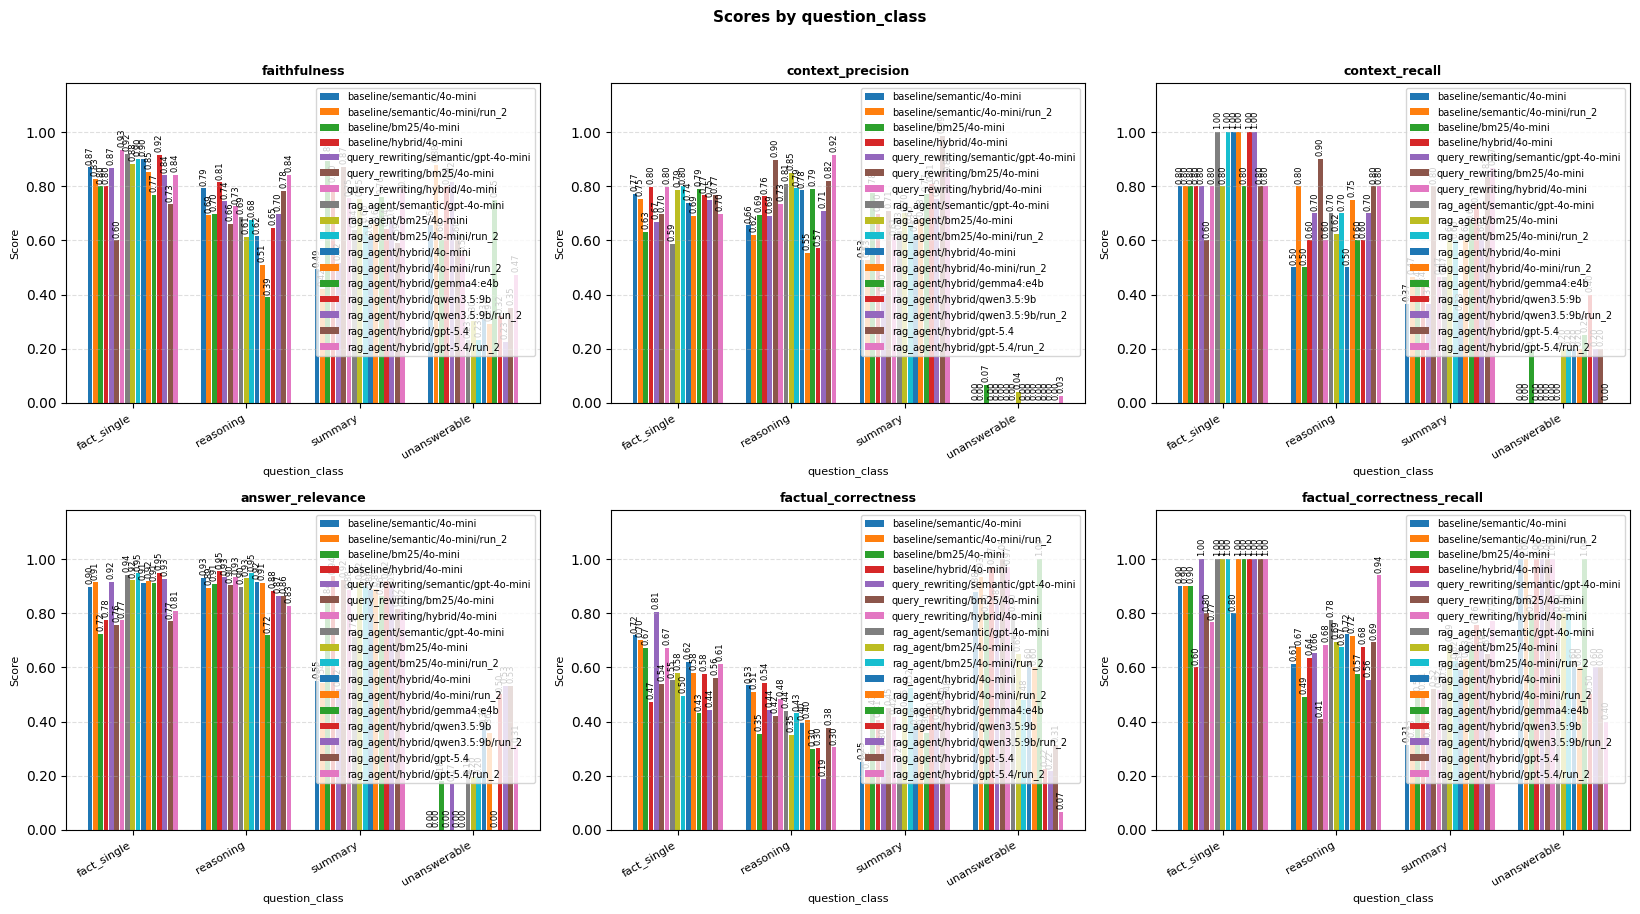

In [27]:
plot_by_group(by_qclass, group_name="question_class")

---
## 3. By `subdomain` (excluding specified question classes)

In [28]:
print(f"Excluding question classes: {EXCLUDE_QUESTION_CLASSES or 'none'}")
by_subdomain = build_comparison(group_col="subdomain", exclude_classes=EXCLUDE_QUESTION_CLASSES)
display(by_subdomain)

Excluding question classes: ['unanswerable']


metric                                                          faithfulness                                                                                                                     \
run                                                baseline/semantic/4o-mini baseline/semantic/4o-mini/run_2 baseline/bm25/4o-mini baseline/hybrid/4o-mini query_rewriting/semantic/gpt-4o-mini   
subdomain                                                                                                                                                                                         
experiment_tracking_fundamentals                                      0.8542                          0.8039                0.6786                  0.8500                               0.9566   
mlflow_tracking_api                                                   0.8061                          0.5476                0.4667                  0.4000                               0.6111   
nisq_constraints_and_qsd_constraints                                  0.8157                          0.6746                0.8745                  0.8718                               0.7381   
qiskit-specific_experiment_tracking_using_mlflo...                    0.5167                          0.6667                0.9667                  1.0000                               0.6667   
qprov_provenance_taxonomy                                             0.6000                          0.5455                1.0000                  0.9221                               0.5741   

metric                                                                                                                                                                                             \
run                                                query_rewriting/bm25/4o-mini query_rewriting/hybrid/4o-mini rag_agent/semantic/gpt-4o-mini rag_agent/bm25/4o-mini rag_agent/bm25/4o-mini/run_2   
subdomain                                                                                                                                                                                           
experiment_tracking_fundamentals                                         0.7540                         0.9259                         0.8947                 0.7718                       0.7500   
mlflow_tracking_api                                                      0.4722                         0.6204                         0.7185                 0.5815                       0.6227   
nisq_constraints_and_qsd_constraints                                     0.5311                         0.7381                         0.7614                 0.6764                       0.6450   
qiskit-specific_experiment_tracking_using_mlflo...                       0.8667                         0.9524                         0.8889                 0.8722                       0.9190   
qprov_provenance_taxonomy                                                0.9333                         0.7857                         0.5500                 0.9688                       0.8152   

metric                                                                                                                                                                                                \
run                                                rag_agent/hybrid/4o-mini rag_agent/hybrid/4o-mini/run_2 rag_agent/hybrid/gemma4:e4b rag_agent/hybrid/qwen3.5:9b rag_agent/hybrid/qwen3.5:9b/run_2   
subdomain                                                                                                                                                                                              
experiment_tracking_fundamentals                                     0.5986                         0.5455                      0.5000                      0.7589                            0.9140   
mlflow_tracking_api                                           

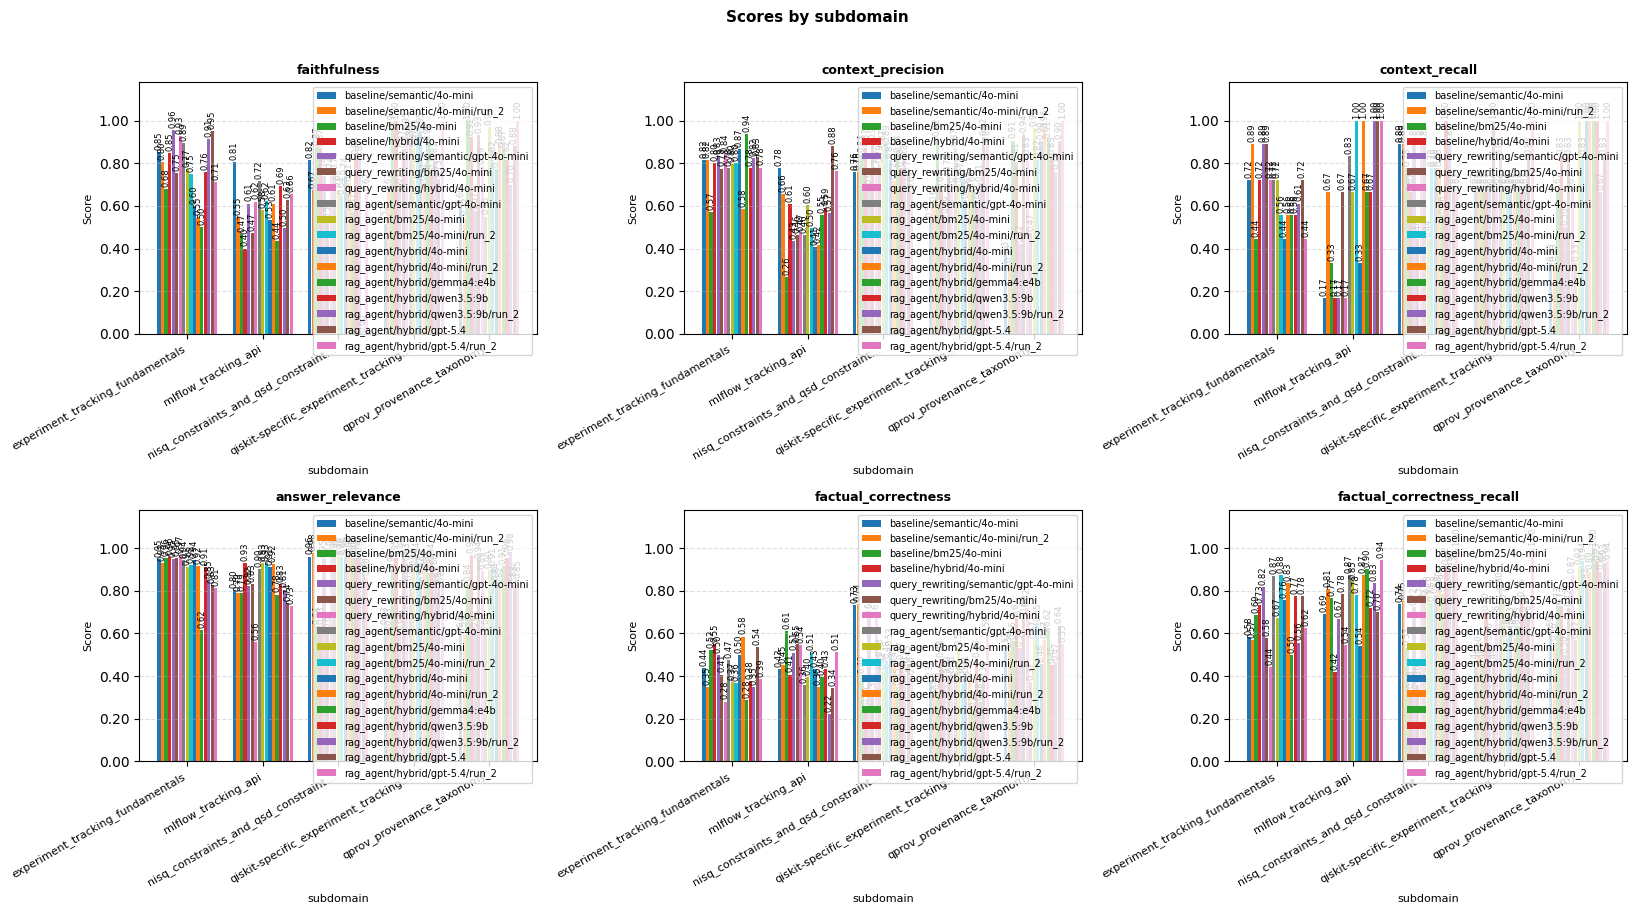

In [29]:
plot_by_group(by_subdomain, group_name="subdomain")

---
## 4. By `(question_class, subdomain)`

In [30]:
by_qclass_subdomain = build_comparison(
    group_col=["question_class", "subdomain"], exclude_classes=None
)
display(by_qclass_subdomain)

metric                                                                         faithfulness                                                                                \
run                                                               baseline/semantic/4o-mini baseline/semantic/4o-mini/run_2 baseline/bm25/4o-mini baseline/hybrid/4o-mini   
question_class subdomain                                                                                                                                                    
fact_single    experiment_tracking_fundamentals                                      1.0000                          1.0000                1.0000                  1.0000   
               mlflow_tracking_api                                                   0.6000                          0.1429                0.0000                  0.0000   
               nisq_constraints_and_qsd_constraints                                  1.0000                          1.0000                1.0000                  1.0000   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.7500                          1.0000                1.0000                  1.0000   
               qprov_provenance_taxonomy                                             1.0000                          1.0000                1.0000                  1.0000   
reasoning      experiment_tracking_fundamentals                                      0.5625                          0.4118                0.2857                     NaN   
               mlflow_tracking_api                                                   1.0000                          0.7500                0.4000                  0.4000   
               nisq_constraints_and_qsd_constraints                                  0.8000                          0.6667                0.8000                  1.0000   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.8000                          1.0000                1.0000                  1.0000   
               qprov_provenance_taxonomy                                             0.8000                          0.6364                1.0000                  0.8571   
summary        experiment_tracking_fundamentals                                      1.0000                          1.0000                0.7500                  0.7000   
               mlflow_tracking_api                                                   0.8182                          0.7500                1.0000                  0.8000   
               nisq_constraints_and_qsd_constraints                                  0.6471                          0.3571                0.8235                  0.6154   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.0000                          0.0000                0.9000                  1.0000   
               qprov_provenance_taxonomy                                             0.0000                          0.0000                1.0000                  0.9091   
unanswerable   experiment_tracking_fundamentals                                      1.0000                          1.0000                1.0000                  1.0000   
               mlflow_tracking_api                                                   0.2857                          0.4000                0.0000                  0.0000   
               nisq_constraints_and_qsd_constraints                                  1.0000                          1.0000                1.0000                  1.0000   
               qiskit-specific_experiment_tracking_using_mlflo...                    0.0000                          1.0000                1.0000                  1.0000   
               qprov_provenance_taxonomy                                             1.0000                          1.0000                0.0000                  1.0000   

metric              

---
## 5. Delta vs. first run

Positive = improvement over the first run in `RUNS`.

In [31]:
if len(run_data) < 2:
    print("Need at least 2 runs to compute deltas.")
else:
    baseline_label = LABELS[0]
    print(f"Delta = run − '{baseline_label}'  (positive = improvement)")
    delta = overall.copy().subtract(overall.loc[baseline_label])
    delta_others = delta.drop(index=baseline_label)
    display(delta_others)

Delta = run − 'baseline/semantic/4o-mini'  (positive = improvement)


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
baseline/semantic/4o-mini/run_2,-0.0709,-0.0176,0.1333,-0.0090,-0.0240,0.0267
baseline/bm25/4o-mini,0.0788,0.0485,0.0222,0.0307,-0.0153,0.0227
baseline/hybrid/4o-mini,0.0873,0.1006,0.0556,0.0960,-0.0267,-0.0267
query_rewriting/semantic/gpt-4o-mini,-0.0092,-0.0639,0.0667,-0.0034,0.0160,0.0542
query_rewriting/bm25/4o-mini,-0.0071,0.1158,0.2111,0.0682,-0.0300,-0.0327
query_rewriting/hybrid/4o-mini,0.0860,0.0631,0.0667,0.0713,0.0240,0.0467
rag_agent/semantic/gpt-4o-mini,0.0348,0.0247,0.1667,0.0570,-0.0860,0.1673
rag_agent/bm25/4o-mini,0.0417,0.1220,0.1230,0.1292,-0.0413,0.1840
rag_agent/bm25/4o-mini/run_2,0.0319,0.0976,0.2111,0.1395,-0.0207,0.1671
rag_agent/hybrid/4o-mini,-0.0029,0.0598,0.0635,0.1115,-0.0347,0.0960


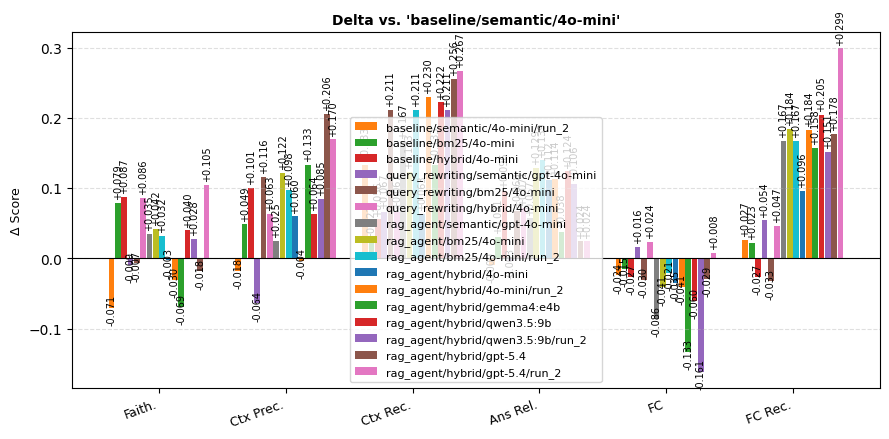

In [32]:
if len(run_data) >= 2:
    metrics = metrics_present_in(overall)
    short   = [METRIC_SHORT.get(m, m) for m in metrics]
    n_runs  = len(delta_others)
    x       = np.arange(len(metrics))
    width   = 0.8 / n_runs

    fig, ax = plt.subplots(figsize=(max(8, len(metrics) * 1.5), 4.5))
    for i, label in enumerate(delta_others.index):
        vals   = delta_others.loc[label, metrics].values.astype(float)
        offset = (i - (n_runs - 1) / 2) * width
        bars   = ax.bar(x + offset, vals, width * 0.9,
                        label=label, color=COLORS[(i + 1) % len(COLORS)])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    v + (0.005 if v >= 0 else -0.025),
                    f"{v:+.3f}", ha="center", va="bottom", fontsize=7, rotation=90
                )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Δ Score", fontsize=9)
    ax.set_title(f"Delta vs. '{baseline_label}'", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

---
## 6. Per-question-class delta vs. first run

In [33]:
if len(run_data) >= 2:
    baseline_label = LABELS[0]
    baseline_qclass = by_qclass.xs(baseline_label, axis=1, level="run")
    for label in LABELS[1:]:
        other   = by_qclass.xs(label, axis=1, level="run")
        delta_q = other - baseline_qclass
        print(f"Delta by question_class: '{label}' − '{baseline_label}'")
        display(delta_q)

Delta by question_class: 'baseline/semantic/4o-mini/run_2' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0414,-0.0167,0.0000,0.0175,-0.0160,0.0000
reasoning,-0.0995,-0.0361,0.3000,-0.0379,-0.0240,0.0600
summary,-0.0716,0.0000,0.1000,-0.0066,-0.0320,0.0200
unanswerable,0.2229,0.0000,0.0000,0.0000,0.0540,0.0000


Delta by question_class: 'baseline/bm25/4o-mini' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0700,-0.1400,0.0000,-0.1738,-0.0460,0.0000
reasoning,-0.0954,0.0372,0.0000,-0.0239,-0.1800,-0.1220
summary,0.4017,0.2483,0.0667,0.2899,0.1800,0.1900
unanswerable,-0.0571,0.0667,0.2000,0.1821,-0.0800,-0.2000


Delta by question_class: 'baseline/hybrid/4o-mini' − 'baseline/semantic/4o-mini'


...

metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0300,-0.0217,0.2000,0.0311,-0.2760,0.1000
reasoning,-0.0949,0.0520,0.2000,-0.0664,-0.3460,-0.0590
summary,0.1784,0.2256,0.2333,0.3547,0.1500,0.3535
unanswerable,-0.4319,0.0000,0.2000,0.5327,-0.6640,-0.4000


Delta by question_class: 'rag_agent/hybrid/gpt-5.4' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.1367,-0.0039,0.0000,-0.1262,-0.1560,0.1000
reasoning,-0.0092,0.1634,0.3000,-0.0678,-0.1565,0.0785
summary,0.0967,0.4576,0.4667,0.2670,0.2060,0.3360
unanswerable,-0.3060,0.0000,0.2000,0.5307,-0.5660,-0.4000


Delta by question_class: 'rag_agent/hybrid/gpt-5.4/run_2' − 'baseline/semantic/4o-mini'


metric,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
question_class,,,,,,
fact_single,-0.0283,-0.0714,0.0000,-0.0886,-0.1060,0.1000
reasoning,0.0496,0.2603,0.3000,-0.1058,-0.2290,0.3260
summary,0.2981,0.3198,0.5000,0.2670,0.2300,0.4560
unanswerable,-0.1853,0.0250,0.0000,0.3131,-0.8140,-0.6000


---
## 7. Raw rows (for custom analysis)

In [34]:
all_rows = pd.concat(run_data.values(), ignore_index=True)
print(f"Total rows: {len(all_rows)}")
cols = ["run_label", "run_id", "user_input", "question_class", "subdomain"] + \
       [c for c in METRIC_COLS if c in all_rows.columns]
all_rows[cols].head(10)

Total rows: 340


,run_label,run_id,user_input,question_class,subdomain,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
0,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,How many qubits are typically found in a NISQ-...,fact_single,nisq_constraints_and_qsd_constraints,1.0000,0.5889,1.0000,0.9536,1.0000,1.0000
1,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What are the primary challenges quantum resear...,summary,nisq_constraints_and_qsd_constraints,0.6471,0.7222,0.6667,0.9508,0.4300,0.5000
2,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Why does the accuracy of my results typically ...,reasoning,nisq_constraints_and_qsd_constraints,0.8000,0.9667,1.0000,0.9777,0.7700,0.7100
3,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the specific hourly cost for accessing...,unanswerable,nisq_constraints_and_qsd_constraints,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
4,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the fundamental unit of organization f...,fact_single,experiment_tracking_fundamentals,1.0000,0.5667,1.0000,1.0000,0.4000,0.5000
5,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What does the experiment tracking process actu...,summary,experiment_tracking_fundamentals,1.0000,0.9167,0.6667,0.9125,0.2900,0.5000
6,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,If my quantum algorithm's source code hasn't c...,reasoning,experiment_tracking_fundamentals,0.5625,0.9667,0.5000,0.9364,0.6200,0.7500
7,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,What is the maximum storage capacity in gigaby...,unanswerable,experiment_tracking_fundamentals,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
8,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Does the QProv definition of circuit width inc...,fact_single,qprov_provenance_taxonomy,1.0000,0.8100,1.0000,0.8885,1.0000,1.0000
9,baseline/semantic/4o-mini,f6d783f661a644a58865384534021c32,Can you give me an overview of the four main c...,summary,qprov_provenance_taxonomy,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
